In [1]:
import torch, urllib.request

if torch.cuda.is_available():
    cap = torch.cuda.get_device_capability(0)
    name = torch.cuda.get_device_name(0)
    print(f"GPU: {name}, compute capability: {cap}")
    print("✅ GPU OK" if cap[0] >= 7 else "⚠️ Wrong GPU — switch to T4 x2 in Settings")
else:
    print("❌ No GPU — check Settings → Accelerator")

try:
    urllib.request.urlopen("https://www.google.com", timeout=5)
    print("✅ Internet ON")
except:
    print("❌ Internet OFF — go to Settings → Internet → toggle On, then re-run this cell")

GPU: Tesla T4, compute capability: (7, 5)
✅ GPU OK
✅ Internet ON


In [2]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd pytorch-CycleGAN-and-pix2pix

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.24 MiB | 23.17 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.
/kaggle/working/pytorch-CycleGAN-and-pix2pix


In [3]:
!pip install dominate visdom -q
# torch and torchvision are already pre-installed on Kaggle — no need to reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
!bash ./datasets/download_pix2pix_dataset.sh facades

Specified [facades]
for details.

--2026-07-20 18:35:13--  http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30168306 (29M) [application/x-gzip]
Saving to: ‘./datasets/facades.tar.gz’

./datasets/facades. 100%[===================>]  28.77M  3.65MB/s    in 12s     

2026-07-20 18:35:26 (2.38 MB/s) - ‘./datasets/facades.tar.gz’ saved [30168306/30168306]

facades/
facades/test/
facades/test/27.jpg
facades/test/5.jpg
facades/test/72.jpg
facades/test/1.jpg
facades/test/10.jpg
facades/test/100.jpg
facades/test/101.jpg
facades/test/102.jpg
facades/test/103.jpg
facades/test/104.jpg
facades/test/105.jpg
facades/test/106.jpg
facades/test/11.jpg
facades/test/12.jpg
facades/test/13.jpg
facades/test/14.jpg
facades/test/15.jpg
facades/test/1

In [5]:
!bash ./scripts/download_pix2pix_model.sh facades_label2photo

Note: available models are edges2shoes, sat2map, map2sat, facades_label2photo, and day2night
Specified [facades_label2photo]
for details.

--2026-07-20 18:35:26--  http://efrosgans.eecs.berkeley.edu/pix2pix/models-pytorch/facades_label2photo.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 217704720 (208M)
Saving to: ‘./checkpoints/facades_label2photo_pretrained/latest_net_G.pth’

./checkpoints/facad 100%[===================>] 207.62M  39.5MB/s    in 5.4s    

2026-07-20 18:35:32 (38.2 MB/s) - ‘./checkpoints/facades_label2photo_pretrained/latest_net_G.pth’ saved [217704720/217704720]



In [6]:
!python test.py \
    --dataroot ./datasets/facades \
    --name facades_label2photo_pretrained \
    --model pix2pix \
    --direction BtoA \
    --num_test 10 \
    --results_dir /kaggle/working/results

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: ./datasets/facades            	[default: None]
             dataset_mode: aligned                       
                direction: BtoA                          	[default: AtoB]
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 

100_fake_B.png


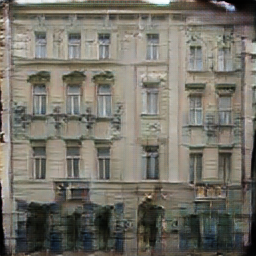

100_real_A.png


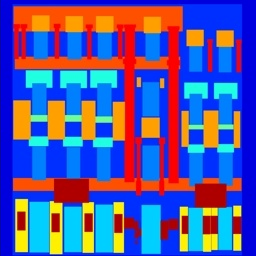

100_real_B.png


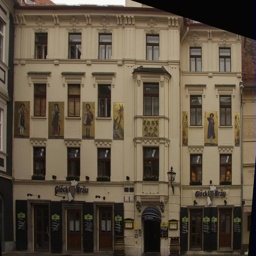

101_fake_B.png


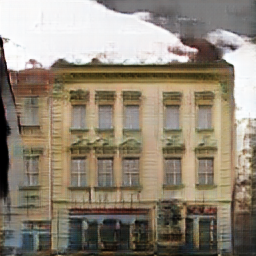

101_real_A.png


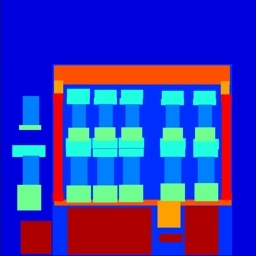

101_real_B.png


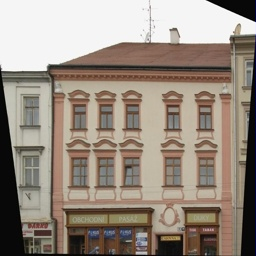

In [7]:
from PIL import Image
import os

results_path = "/kaggle/working/results/facades_label2photo_pretrained/test_latest/images"
files = sorted(os.listdir(results_path))[:6]  # first 6 files

for f in files:
    print(f)
    display(Image.open(os.path.join(results_path, f)))